# Option Data Summary

## Index Data
- **spx2008.csv**  
  - Contains: **SPX options**  
  - Date Range: **6/2/2008 – 12/26/2008**

- **spx2020.csv** (p1)  
  - Contains: **SPX options**  
  - Date Range: **1/24/2020 – 4/30/2020**

- **spx2020p2.csv** (p2)  
  - Contains: **SPX options**  
  - Date Range: **1/2/2020 – 1/23/2020**

## Single-Stock Data
- **data2008.csv**  
  - Contains: **JPM, XOM, MSFT options**  
  - Date Range: **6/2/2008 – 12/26/2008**

- **data2020.csv**  
  - Contains: **JPM, XOM, MSFT options**  
  - Date Range: **1/2/2020 – 4/30/2020**


## Strategy with Z-Scores

In [1]:
# Option C (Z-Score) Workflow — ready-to-run template

import pandas as pd
import numpy as np
from math import log, sqrt, exp
from scipy.stats import norm
from scipy.optimize import brentq

# ---------- Load data (8 datasets) ----------
def load_all():
    spx2008 = pd.read_csv("spx2008.csv", parse_dates=["date","expiration"])
    spx2020_p1 = pd.read_csv("spx2020.csv", parse_dates=["date","expiration"])
    spx2020_p2 = pd.read_csv("spx2020p2.csv", parse_dates=["date","expiration"])
    spx2020 = pd.concat([spx2020_p1, spx2020_p2], ignore_index=True).sort_values("date")

    data2008 = pd.read_csv("data2008.csv", parse_dates=["date","expiration"])
    data2020 = pd.read_csv("data2020.csv", parse_dates=["date","expiration"])

    jpm2008 = data2008[data2008["symbol"]=="JPM"].reset_index(drop=True)
    jpm2020 = data2020[data2020["symbol"]=="JPM"].reset_index(drop=True)
    xom2008 = data2008[data2008["symbol"]=="XOM"].reset_index(drop=True)
    xom2020 = data2020[data2020["symbol"]=="XOM"].reset_index(drop=True)
    msft2008 = data2008[data2008["symbol"]=="MSFT"].reset_index(drop=True)
    msft2020 = data2020[data2020["symbol"]=="MSFT"].reset_index(drop=True)
    return spx2008, spx2020, jpm2008, jpm2020, xom2008, xom2020, msft2008, msft2020

spx2008, spx2020, jpm2008, jpm2020, xom2008, xom2020, msft2008, msft2020 = load_all()

In [2]:
# ---------- Black–Scholes helpers + IV solver ----------
def _bs_price_call(S, K, r, T, sigma):
    if T <= 0 or sigma <= 0: return max(S-K, 0.0)
    d1 = (np.log(S/K) + (r + 0.5*sigma*sigma)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def _bs_price_put(S, K, r, T, sigma):
    if T <= 0 or sigma <= 0: return max(K-S, 0.0)
    d1 = (np.log(S/K) + (r + 0.5*sigma*sigma)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def implied_vol(mid_price, S, K, r, T, is_call=True):
    if mid_price <= 0 or S <= 0 or K <= 0 or T <= 0: return np.nan
    def f(sigma):
        price = _bs_price_call(S,K,r,T,sigma) if is_call else _bs_price_put(S,K,r,T,sigma)
        return price - mid_price
    try:
        return float(brentq(f, 1e-6, 5.0, maxiter=100, disp=False))
    except Exception:
        return np.nan

In [3]:
# ---------- DTE & strike selection ----------
def add_dte(df):
    dte_days = (df["expiration"] - df["date"]).dt.days
    return df.assign(dte_days=dte_days, T_years=dte_days/365.0)

def pick_strikes_for_smirk(chain_day, spot, otm_put_moneyness=0.95):
    calls = chain_day[chain_day["call/put"]=="C"]
    puts  = chain_day[chain_day["call/put"]=="P"]
    if calls.empty or puts.empty: return None, None

    atm_call = calls.iloc[(calls["strike"] - spot).abs().argsort()[:1]]
    target_put_strike = otm_put_moneyness * spot
    candidate_puts = puts[puts["strike"] <= spot]
    if candidate_puts.empty: return atm_call, None
    otm_put = candidate_puts.iloc[(candidate_puts["strike"] - target_put_strike).abs().argsort()[:1]]
    return atm_call, otm_put

def midprice_valid(row):
    bid, ask = row["bid"], row["ask"]
    if pd.isna(bid) or pd.isna(ask): return np.nan
    if bid <= 0 or ask <= 0: return np.nan
    if ask < bid: return np.nan
    return 0.5*(bid + ask)

In [4]:
# ---------- Smirk for one (ticker, date, DTE window) ----------
def compute_smirk_for_day(df, date, dte_target, dte_tol, r_annual=0.01, otm_put_moneyness=0.95):
    day_chain = df[df["date"]==date]
    if day_chain.empty:
        return {"date": date, "smirk_norm": np.nan, "iv_put": np.nan, "iv_call": np.nan, "dte_used": np.nan}

    spot = day_chain["adjusted close"].iloc[0]
    sub = add_dte(day_chain)
    sub = sub[sub["dte_days"].between(dte_target - dte_tol, dte_target + dte_tol)]
    if sub.empty:
        return {"date": date, "smirk_norm": np.nan, "iv_put": np.nan, "iv_call": np.nan, "dte_used": np.nan}

    atm_call, otm_put = pick_strikes_for_smirk(sub, spot, otm_put_moneyness)
    if atm_call is None or otm_put is None:
        return {"date": date, "smirk_norm": np.nan, "iv_put": np.nan, "iv_call": np.nan, "dte_used": np.nan}

    atm_row, put_row = atm_call.iloc[0].copy(), otm_put.iloc[0].copy()
    mid_call, mid_put = midprice_valid(atm_row), midprice_valid(put_row)
    if pd.isna(mid_call) or pd.isna(mid_put):
        return {"date": date, "smirk_norm": np.nan, "iv_put": np.nan, "iv_call": np.nan, "dte_used": np.nan}

    T_call = max(atm_row["T_years"], 1e-6)
    T_put  = max(put_row["T_years"], 1e-6)
    iv_call = implied_vol(mid_call, spot, atm_row["strike"], r_annual, T_call, is_call=True)
    iv_put  = implied_vol(mid_put,  spot, put_row["strike"], r_annual, T_put,  is_call=False)
    if np.isnan(iv_call) or np.isnan(iv_put) or iv_call <= 0:
        return {"date": date, "smirk_norm": np.nan, "iv_put": iv_put, "iv_call": iv_call, "dte_used": float(np.nan)}

    smirk_raw = iv_put - iv_call
    smirk_norm = smirk_raw / iv_call
    return {"date": date, "smirk_norm": smirk_norm, "iv_put": iv_put, "iv_call": iv_call, "dte_used": float(atm_row["dte_days"])}

In [5]:
# ---------- Mondays/Tuesdays smirk series ----------
def get_business_days(df):
    d = df[["date","adjusted close"]].drop_duplicates().sort_values("date")
    d["weekday"] = d["date"].dt.weekday  # Monday=0 ... Friday=4
    return d

def smirk_series(df_symbol, year):
    dcal = get_business_days(df_symbol)
    dcal = dcal[dcal["date"].dt.year == year]
    dcal = dcal[dcal["weekday"].isin([0,1])]  # Mon/Tue
    dates = dcal["date"].tolist()

    rows = []
    if year == 2020:
        targets, tol = [7,14,21,28], 3
    else:  # 2008 monthly proxy
        targets, tol = [30], 10

    for dt in dates:
        out = {"date": dt}
        for t in targets:
            res = compute_smirk_for_day(df_symbol, dt, dte_target=t, dte_tol=tol)
            out[f"smirk_norm_{t}d"] = res["smirk_norm"]
            out[f"dte_used_{t}d"] = res["dte_used"]
        rows.append(out)
    return pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

In [6]:
# ---------- Z-scores (rolling) ----------
def add_zscores(sm_df, cols, lookback=60, min_periods=30, method="rolling"):
    df = sm_df.copy()
    for c in cols:
        if method == "rolling":
            mu = df[c].rolling(lookback, min_periods=min_periods).mean()
            sd = df[c].rolling(lookback, min_periods=min_periods).std()
        else:
            mu = df[c].expanding(min_periods=min_periods).mean()
            sd = df[c].expanding(min_periods=min_periods).std()
        df[c+"_z"] = (df[c] - mu) / sd
    return df

In [7]:
# ---------- Mon/Tue -> Fri outcome (underlying return) ----------
def weekly_outcome(df_symbol, dates):
    dpx = df_symbol[["date","adjusted close"]].drop_duplicates().sort_values("date").reset_index(drop=True)
    dpx["weekday"] = dpx["date"].dt.weekday
    dpx["week"] = dpx["date"].dt.isocalendar().week.astype(int)
    dpx["year"] = dpx["date"].dt.year

    outs = []
    for dt in dates:
        wk, yr = int(dt.isocalendar().week), int(dt.year)
        wk_rows = dpx[(dpx["week"]==wk) & (dpx["year"]==yr)]
        fri = wk_rows[wk_rows["weekday"]==4]
        fri_row = fri.iloc[-1:] if not fri.empty else (wk_rows.iloc[-1:] if not wk_rows.empty else None)
        p0 = dpx.loc[dpx["date"]==dt, "adjusted close"]
        if fri_row is None or fri_row.empty or p0.empty:
            outs.append({"date": dt, "ret_mtf": np.nan})
            continue
        ret = (float(fri_row["adjusted close"].iloc[0]) - float(p0.iloc[0])) / float(p0.iloc[0])
        outs.append({"date": dt, "ret_mtf": ret})
    return pd.DataFrame(outs)

In [8]:
# ---------- End-to-end runner ----------
def run_zscore_strategy(df_symbol, year, z_col="smirk_norm_7d_z", z_buy_put=1.0, z_buy_call=-1.0):
    sm = smirk_series(df_symbol, year)
    sm_cols = [c for c in sm.columns if c.startswith("smirk_norm_")]
    sm_z = add_zscores(sm, sm_cols, lookback=4, min_periods=2, method="rolling")
    outcomes = weekly_outcome(df_symbol, sm_z["date"].tolist())
    out = sm_z.merge(outcomes, on="date", how="left")

    if z_col not in out.columns:
        z_col = sm_cols[0] + "_z"

    def decide(z):
        if pd.isna(z): return "NO_TRADE"
        if z >= z_buy_put:  return "PUT"
        if z <= z_buy_call: return "CALL"
        return "NO_TRADE"

    out["signal"] = out[z_col].apply(decide)

    def is_correct(row):
        if row["signal"] == "PUT":  return 1 if row["ret_mtf"] < 0 else 0
        if row["signal"] == "CALL": return 1 if row["ret_mtf"] > 0 else 0
        return np.nan

    out["correct"] = out.apply(is_correct, axis=1)
    return out

In [9]:
def hit_rate(df):
    out = df.copy()
    out = out[out["signal"]!="NO_TRADE"]
    return out["correct"].mean(), out["signal"].value_counts()

In [10]:
# Symbols to run
symbols = {
    "SPX": {"2008": spx2008, "2020": spx2020},
    "JPM": {"2008": jpm2008, "2020": jpm2020},
    "XOM": {"2008": xom2008, "2020": xom2020},
    "MSFT": {"2008": msft2008, "2020": msft2020},
}

# Choose z-score columns per year
z_col_by_year = {2008: "smirk_norm_30d_z", 2020: "smirk_norm_7d_z"}

# Thresholds (looser to generate more signals in short samples)
Z_PUT = 0.5
Z_CALL = -1.25

# Run, save, and collect summary
summary_rows = []
paths = []

for sym, years in symbols.items():
    for yr_str, df in years.items():
        yr = int(yr_str)
        zcol = z_col_by_year[yr]
        try:
            res = run_zscore_strategy(df, yr, z_col=zcol, z_buy_put=Z_PUT, z_buy_call=Z_CALL)
        except Exception as e:
            # fallback to auto-select first z column if specified zcol is missing
            res = run_zscore_strategy(df, yr, z_col="auto", z_buy_put=Z_PUT, z_buy_call=Z_CALL)

        # Save CSV
        out_path = f"res_{sym.lower()}_{yr}.csv"
        res.to_csv(out_path, index=False)
        paths.append(out_path)

        # Hit rate
        hr, counts = hit_rate(res)
        summary_rows.append({
            "symbol": sym,
            "year": yr,
            "hit_rate": hr,
            "n_trades": int((res["signal"]!="NO_TRADE").sum()),
            "n_calls": int((res["signal"]=="CALL").sum()),
            "n_puts": int((res["signal"]=="PUT").sum()),
            "n_no_trade": int((res["signal"]=="NO_TRADE").sum()),
            "z_col_used": zcol
        })

# Build summary table
summary = pd.DataFrame(summary_rows).sort_values(["year","symbol"]).reset_index(drop=True)

# Display quick peek
summary

,symbol,year,hit_rate,n_trades,n_calls,n_puts,n_no_trade,z_col_used
0,JPM,2008,0.631579,19,1,18,40,smirk_norm_30d_z
1,MSFT,2008,0.733333,15,3,12,44,smirk_norm_30d_z
2,SPX,2008,0.470588,17,2,15,42,smirk_norm_30d_z
3,XOM,2008,0.368421,19,2,17,40,smirk_norm_30d_z
4,JPM,2020,0.363636,11,3,8,21,smirk_norm_7d_z
5,MSFT,2020,0.272727,11,3,8,21,smirk_norm_7d_z
6,SPX,2020,0.454545,11,2,9,21,smirk_norm_7d_z
7,XOM,2020,0.333333,12,2,10,20,smirk_norm_7d_z


## Strategy with Percentiles

In [11]:
def run_percentile_strategy(df_symbol, year, smirk_col_for_2020="smirk_norm_7d", smirk_col_for_2008="smirk_norm_30d",
                            p_low=0.30, p_high=0.70):
    """
    Build Monday/Tuesday smirk series for the given (symbol, year),
    then create percentile-based signals:
        - smirk <= p_low percentile  -> CALL (bullish)
        - smirk >= p_high percentile -> PUT  (bearish)
        - otherwise                  -> NO_TRADE
    Outcome is Mon/Tue -> Fri underlying return.
    Returns dataframe with columns: date, smirk columns, signal_pct, correct_pct, ret_mtf
    """
    # 1) Compute smirk series (Mon/Tue rows only)
    sm = smirk_series(df_symbol, year)
    
    # 2) Choose which smirk column to use (matches your z-score setup)
    sm_col = smirk_col_for_2020 if year == 2020 else smirk_col_for_2008
    if sm_col not in sm.columns:
        # fallback to the first smirk column available
        sm_col = [c for c in sm.columns if c.startswith("smirk_norm_")][0]
    
    # 3) Compute percentile thresholds on the available sample (time-series percentiles for this stock/year)
    low_thr  = sm[sm_col].quantile(p_low)
    high_thr = sm[sm_col].quantile(p_high)
    
    # 4) Build signals
    def decide(x):
        if pd.isna(x): return "NO_TRADE"
        if x >= high_thr: return "PUT"
        if x <= low_thr:  return "CALL"
        return "NO_TRADE"
    sm["signal_pct"] = sm[sm_col].apply(decide)
    
    # 5) Weekly outcome (Mon/Tue -> Fri returns of the underlying)
    outcomes = weekly_outcome(df_symbol, sm["date"].tolist())
    out = sm.merge(outcomes, on="date", how="left")
    
    # 6) Correctness label (directional accuracy)
    def is_correct(row):
        if row["signal_pct"] == "PUT":  return 1 if row["ret_mtf"] < 0 else 0
        if row["signal_pct"] == "CALL": return 1 if row["ret_mtf"] > 0 else 0
        return np.nan
    out["correct_pct"] = out.apply(is_correct, axis=1)
    
    # 7) Attach metadata (thresholds used)
    out.attrs["pct_thresholds"] = {"low": float(low_thr), "high": float(high_thr), "smirk_col_used": sm_col}
    return out


def hit_rate_percentile(df):
    """Hit rate for percentile-based signals (uses 'signal_pct' and 'correct_pct')."""
    sub = df[df["signal_pct"]!="NO_TRADE"]
    if sub.empty:
        return np.nan, {"NO_TRADE": len(df)}
    return sub["correct_pct"].mean(), sub["signal_pct"].value_counts().to_dict()

# ------- Batch runner to mirror your earlier loop -------
def batch_percentile_all(p_low=0.30, p_high=0.70):
    symbols = {
        "SPX": {"2008": spx2008, "2020": spx2020},
        "JPM": {"2008": jpm2008, "2020": jpm2020},
        "XOM": {"2008": xom2008, "2020": xom2020},
        "MSFT": {"2008": msft2008, "2020": msft2020},
    }
    rows = []
    paths = []
    for sym, years in symbols.items():
        for yr_str, df in years.items():
            yr = int(yr_str)
            res = run_percentile_strategy(df, yr, p_low=p_low, p_high=p_high)
            # Save
            path = f"res_{sym.lower()}_{yr}_pct.csv"
            res.to_csv(path, index=False)
            paths.append(path)
            # Summary
            hr, counts = hit_rate_percentile(res)
            rows.append({
                "symbol": sym,
                "year": yr,
                "hit_rate_pct": hr,
                "n_trades": int((res["signal_pct"]!="NO_TRADE").sum()),
                "n_calls": int((res["signal_pct"]=="CALL").sum()),
                "n_puts": int((res["signal_pct"]=="PUT").sum()),
                "n_no_trade": int((res["signal_pct"]=="NO_TRADE").sum()),
                "smirk_col_used": res.attrs.get("pct_thresholds", {}).get("smirk_col_used", "NA"),
                "low_thr": res.attrs.get("pct_thresholds", {}).get("low", np.nan),
                "high_thr": res.attrs.get("pct_thresholds", {}).get("high", np.nan),
            })
    summary_pct = pd.DataFrame(rows).sort_values(["year","symbol"]).reset_index(drop=True)
    return summary_pct, paths

# To run the batch and see a summary table, uncomment:
summary_pct, csv_paths = batch_percentile_all(p_low=0.15, p_high=0.85)
summary_pct

,symbol,year,hit_rate_pct,n_trades,n_calls,n_puts,n_no_trade,smirk_col_used,low_thr,high_thr
0,JPM,2008,0.642857,14,7,7,45,smirk_norm_30d,-0.013096,0.192176
1,MSFT,2008,0.714286,14,7,7,45,smirk_norm_30d,0.019827,0.122078
2,SPX,2008,0.500000,14,7,7,45,smirk_norm_30d,0.053111,0.208292
3,XOM,2008,0.714286,14,7,7,45,smirk_norm_30d,-0.044077,0.143624
4,JPM,2020,0.600000,10,5,5,22,smirk_norm_7d,0.049784,0.353831
5,MSFT,2020,0.400000,10,5,5,22,smirk_norm_7d,0.011777,0.279694
6,SPX,2020,0.400000,10,5,5,22,smirk_norm_7d,0.098031,0.828738
7,XOM,2020,0.800000,10,5,5,22,smirk_norm_7d,-0.010176,0.327571


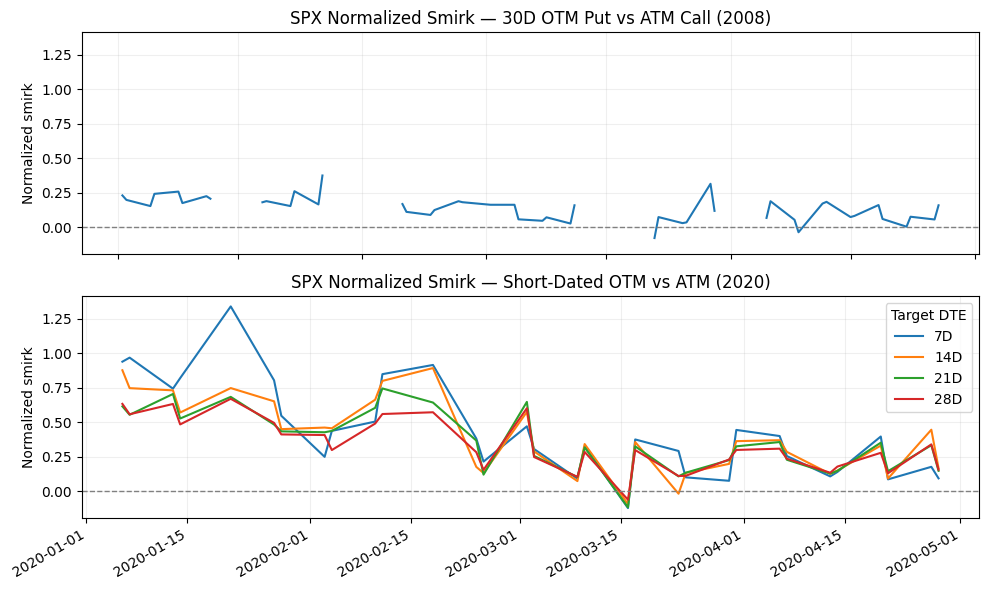

In [12]:
import matplotlib.pyplot as plt

# Build SPX smirk series for each crisis year
spx_smirk_2008 = smirk_series(spx2008, 2008)   # uses smirk_norm_30d
spx_smirk_2020 = smirk_series(spx2020, 2020)   # uses smirk_norm_7d,14d,21d,28d

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharey=True)

# --- Panel A: 2008 (monthly ~30D maturity) ---
axes[0].plot(
    spx_smirk_2008["date"],
    spx_smirk_2008["smirk_norm_30d"],
)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("SPX Normalized Smirk — 30D OTM Put vs ATM Call (2008)")
axes[0].set_ylabel("Normalized smirk")
axes[0].grid(alpha=0.2)

# --- Panel B: 2020 (short-dated maturities) ---
for col, label in [
    ("smirk_norm_7d", "7D"),
    ("smirk_norm_14d", "14D"),
    ("smirk_norm_21d", "21D"),
    ("smirk_norm_28d", "28D"),
]:
    if col in spx_smirk_2020.columns:
        axes[1].plot(spx_smirk_2020["date"], spx_smirk_2020[col], label=label)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("SPX Normalized Smirk — Short-Dated OTM vs ATM (2020)")
axes[1].set_ylabel("Normalized smirk")
axes[1].grid(alpha=0.2)
axes[1].legend(title="Target DTE")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()